# Part 3 — Overlays and diagnostics

This notebook reloads the graph and adds one slice per organelle. A slice is a
membership overlay on the shared graph and duplicates no topology. The common
alternative keeps one graph object per compartment. The notebook then reports
counts per aspect and re-saves the snapshot with the slices attached.

In [2]:
from collections import defaultdict

import pandas as pd

from uc2_common import *  # noqa: F403

G = load()
V = G.views.vertices().to_pandas()
prot = V[V.vertex_id.str.startswith("prot:")]

by_comp = defaultdict(set)
for r in prot.itertuples(index=False):
    name = CODE_TO_NAME.get(getattr(r, "compartment", None))
    if name:
        by_comp[name].add(r.vertex_id)

rows = []
for name, vids in by_comp.items():
    if G.slices.exists(name):
        continue
    G.slices.add(name)
    for v in vids:
        G.slices.add_vertex_to_slice(name, v)
    eids = [e for e, (s, t, _) in G.edge_definitions.items() if bare_vid(s) in vids and bare_vid(t) in vids]
    G.slices.add_edges(name, eids)
    rows.append({"slice": name, "vertices": len(G.slices.vertices(name)), "edges": len(G.slices.edges(name))})

G.history.snapshot("after_organelle_slices")
sl = pd.DataFrame(rows).sort_values("vertices", ascending=False)
sl.to_csv(TABLES / "organelle_slices.csv", index=False)
print(sl.to_string(index=False))

          slice  vertices  edges
        cytosol      8743   5783
        nucleus      5402   5931
plasma_membrane      1141    656
       vesicles      1081     98
   mitochondria       966     59
          golgi       746     55
             er       440     32
     peroxisome        21      1
       lysosome        18      0


## Diagnostics

The panel reports counts by molecule `kind` and by `edge_kind`, the totals per
`mechanism`, and the `member`/`monomer` split of the `complex` aspect.

vertices by kind:
 kind
protein       18564
metabolite     8455
gene           5197
boundary          2

edges by edge_kind:
 edge_kind
signaling               31898
regulatory              14999
None                    12971
coupling_translation     5197
complex                  4456
coupling_tf_anchor        367

supra-nodes per mechanism: {'signaling': 18557, 'metabolic': 8457, 'regulatory': 5197}
complex aspect (proteins): member=10,831  monomer=7,726


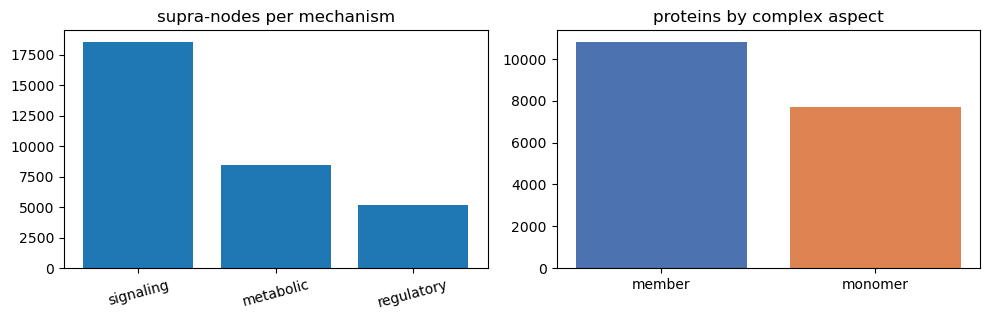

re-saved snapshot with 20 slices


In [3]:
import matplotlib.pyplot as plt

E = edges_frame(G)
print("vertices by kind:\n", V["kind"].value_counts().to_string())
print("\nedges by edge_kind:\n", E["edge_kind"].value_counts(dropna=False).to_string())

mech = {m: len(G.layers.layer_vertex_set((m, CPLX_MEMBER)) | G.layers.layer_vertex_set((m, CPLX_MONOMER)))
        for m in MECHANISMS}
member = len(G.layers.layer_vertex_set((MECH_SIGNALING, CPLX_MEMBER)))
monomer = len(G.layers.layer_vertex_set((MECH_SIGNALING, CPLX_MONOMER)))
print(f"\nsupra-nodes per mechanism: {mech}")
print(f"complex aspect (proteins): member={member:,}  monomer={monomer:,}")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.3))
ax[0].bar(list(mech), list(mech.values())); ax[0].set_title("supra-nodes per mechanism")
ax[0].tick_params(axis="x", rotation=15)
ax[1].bar(["member", "monomer"], [member, monomer], color=["#4c72b0", "#dd8452"])
ax[1].set_title("proteins by complex aspect")
fig.tight_layout(); fig.savefig(FIGS / "aspect_topology.png", dpi=120); plt.show()

G.write(str(SNAPSHOT), overwrite=True)  # persist the slices for later notebooks
print("re-saved snapshot with", len(G.slices.list()), "slices")